# Auto-Filter → DARTS End-to-End Example

Pipeline:
1. Generate a noisy synthetic time series
2. Use `auto_filter` to automatically select and apply the best denoising filter
3. Feed the cleaned signal into DARTS NAS multi-fidelity search for forecasting
4. Evaluate the final model and visualise results

In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

from foreblocks.darts import DARTSTrainer
from foreblocks.ts_handler.auto_filter import (
    auto_filter,
    plot_results,
    _FILTER_REGISTRY,
    _SLOW_FILTERS,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_float32_matmul_precision("high")
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True

print(f"Device: {DEVICE}")

Device: cuda


## 1. Synthetic noisy time series

A single-channel signal composed of:
- a slow quadratic trend
- a dominant annual seasonal cycle (period 52 weeks)
- a quarterly harmonic (period 13 weeks)
- Gaussian noise (SNR ≈ 8 dB — noticeably noisy)

N=3120  noise_std=0.8  SNR≈15.4 dB


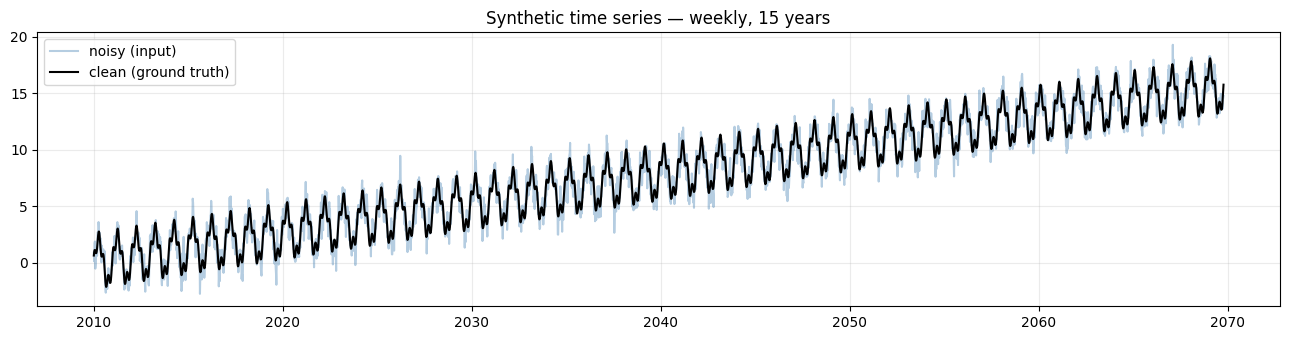

In [2]:
rng = np.random.default_rng(SEED)
N = 1560*2
t = np.arange(N, dtype=float)
dates = pd.date_range("2010-01-01", periods=N, freq="W")

trend    = 0.005 * t
seasonal = 2.0  * np.sin(2 * np.pi * t / 52)
harmonic = 0.7  * np.sin(2 * np.pi * t / 13 + 1.1)
clean_arr = trend + seasonal + harmonic

noise_std = 0.8
noisy_arr = clean_arr + rng.normal(0, noise_std, N)

ts_clean = pd.Series(clean_arr, index=dates, name="clean")
ts_noisy = pd.Series(noisy_arr, index=dates, name="noisy")

snr_db = 10 * np.log10(np.var(clean_arr) / np.var(noisy_arr - clean_arr))
print(f"N={N}  noise_std={noise_std}  SNR≈{snr_db:.1f} dB")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(dates, ts_noisy, alpha=0.4, color="steelblue", label="noisy (input)")
ax.plot(dates, ts_clean, color="black", linewidth=1.5, label="clean (ground truth)")
ax.set_title("Synthetic time series — weekly, 15 years")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 2. Automatic filter selection with `auto_filter`

`auto_filter` runs all fast filters and ranks them by a composite unsupervised score.
No ground-truth is required — the scoring uses fidelity, roughness, residual autocorrelation, and derivative correlation.

In [3]:
best_name, ts_filtered, score_table = auto_filter(ts_noisy, fast=True)

print(f"Best filter: {best_name!r}")
print(f"\nScore table (lower = better):")
print(score_table.to_string(float_format="{:.4f}".format))

mse_noisy_vs_clean    = float(np.mean((ts_noisy.values  - clean_arr)**2))
mse_filtered_vs_clean = float(np.mean((ts_filtered.values - clean_arr)**2))
print(f"\nMSE vs ground truth:")
print(f"  noisy    : {mse_noisy_vs_clean:.4f}")
print(f"  filtered : {mse_filtered_vs_clean:.4f}  ({100*(1 - mse_filtered_vs_clean/mse_noisy_vs_clean):.1f}% reduction)")

Best filter: 'TV Denoising'

Score table (lower = better):
                         fidelity_mse  roughness  residual_autocorr  derivative_corr  score
TV Denoising                   0.1527     0.6301             0.0426           0.8850 0.1308
Kalman RTS                     0.1580     0.5421             0.0485           0.9255 0.1731
Wavelet (Bayes+Garrote)        0.3360     0.3627             0.0465           0.6297 0.2385
Bilateral                      0.1682     0.6632             0.1138           0.9639 0.3154
Gaussian                       0.5037     0.2425             0.0554           0.3254 0.3385
FFT Denoising                  0.4664     0.3827             0.0636           0.3033 0.4308
Savitzky-Golay                 0.5106     0.3253             0.0612           0.2216 0.4962
Butterworth Lowpass            0.5854     0.2140             0.0795           0.2563 0.5269
Moving Average                 0.5876     0.2667             0.0631           0.1791 0.5808
EMD+VMD Baseline     

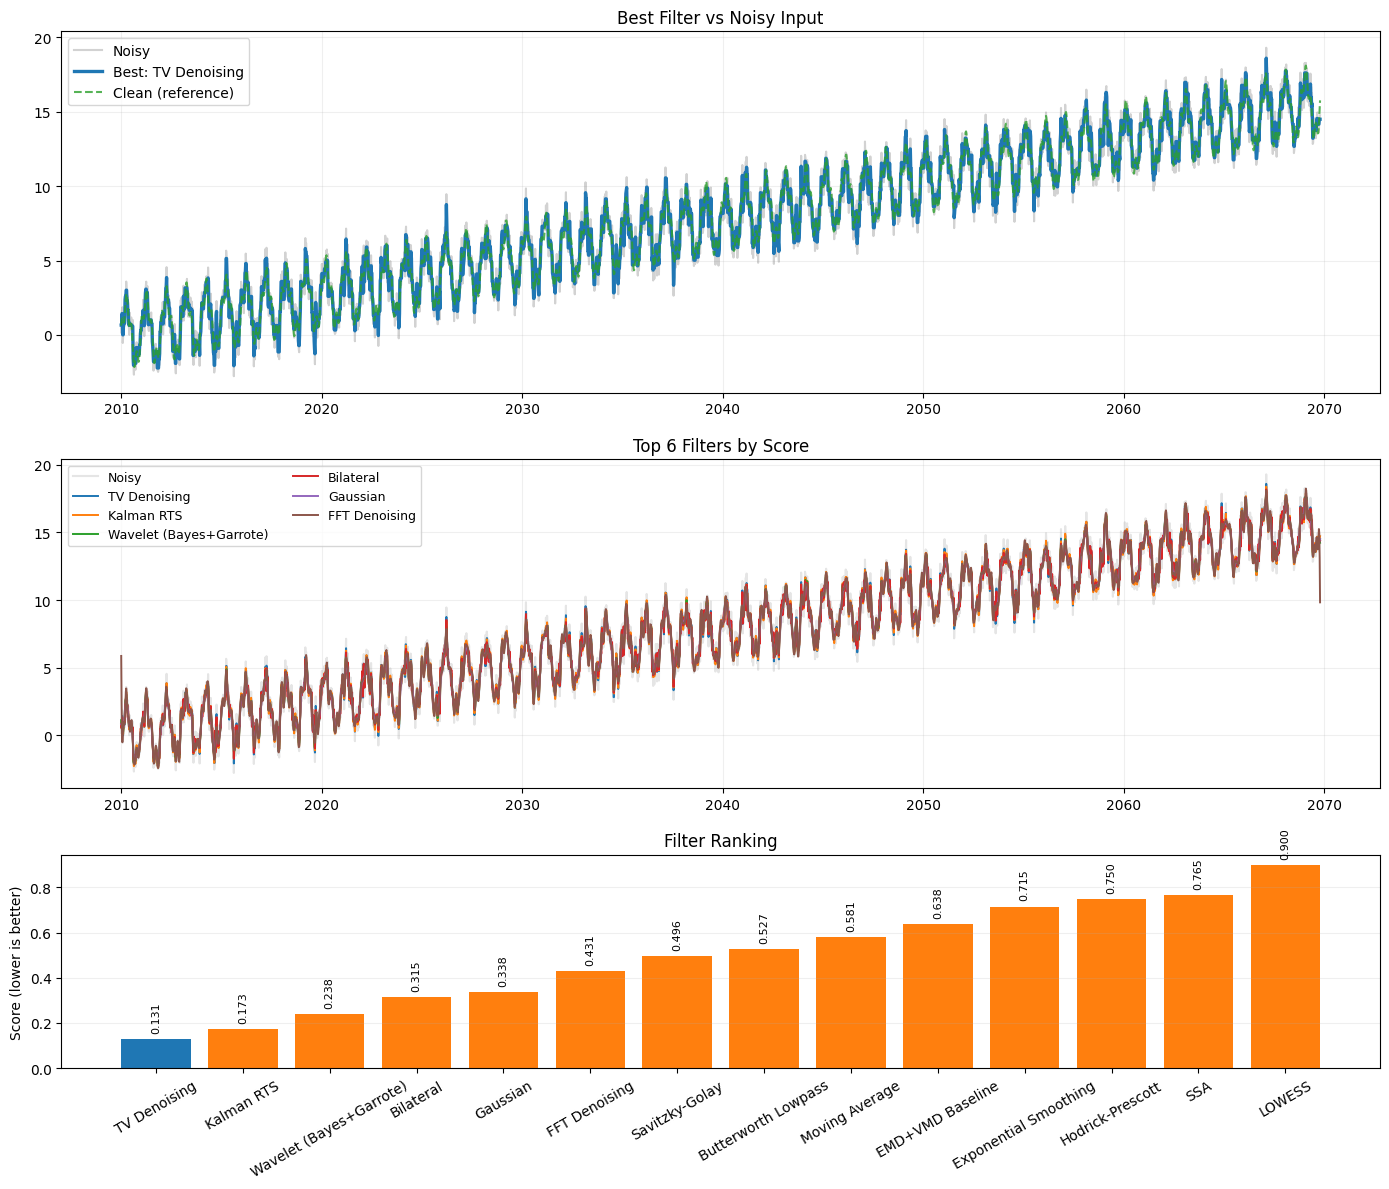

In [4]:
# Build candidates dict for plot_results (re-runs fast filters)
candidates = {}
for name, fn in _FILTER_REGISTRY.items():
    if name in _SLOW_FILTERS:
        continue
    try:
        candidates[name] = fn(ts_noisy)
    except Exception:
        pass

fig = plot_results(ts_noisy, score_table, candidates, best_name, clean=ts_clean, top_k=6)
plt.show()

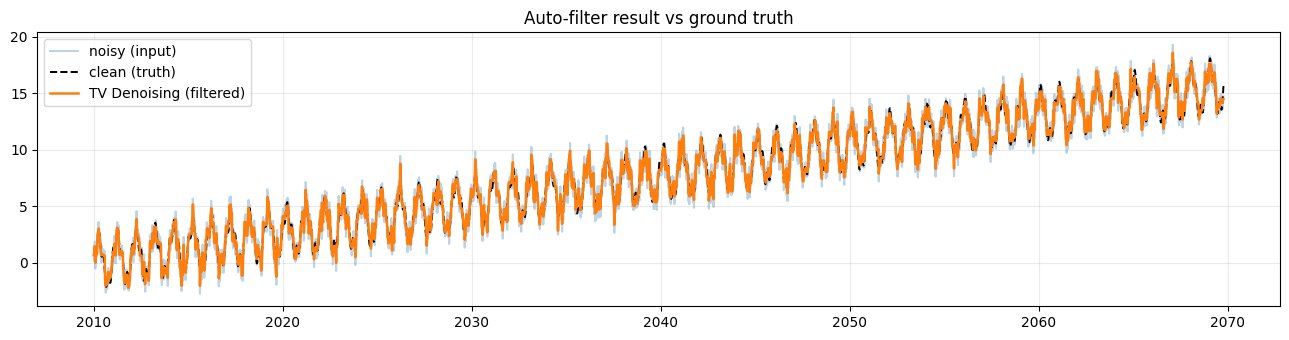

In [5]:
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(dates, ts_noisy,    alpha=0.35, color="steelblue", label="noisy (input)")
ax.plot(dates, ts_clean,    color="black",  linewidth=1.4, linestyle="--", label="clean (truth)")
ax.plot(dates, ts_filtered, color="tab:orange", linewidth=1.8, label=f"{best_name} (filtered)")
ax.set_title("Auto-filter result vs ground truth")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

## 3. Prepare DARTS DataLoaders

The filtered series is normalised and split into sliding windows.
DARTS expects `(B, seq_len, n_channels)` input and `(B, horizon, n_channels)` targets.

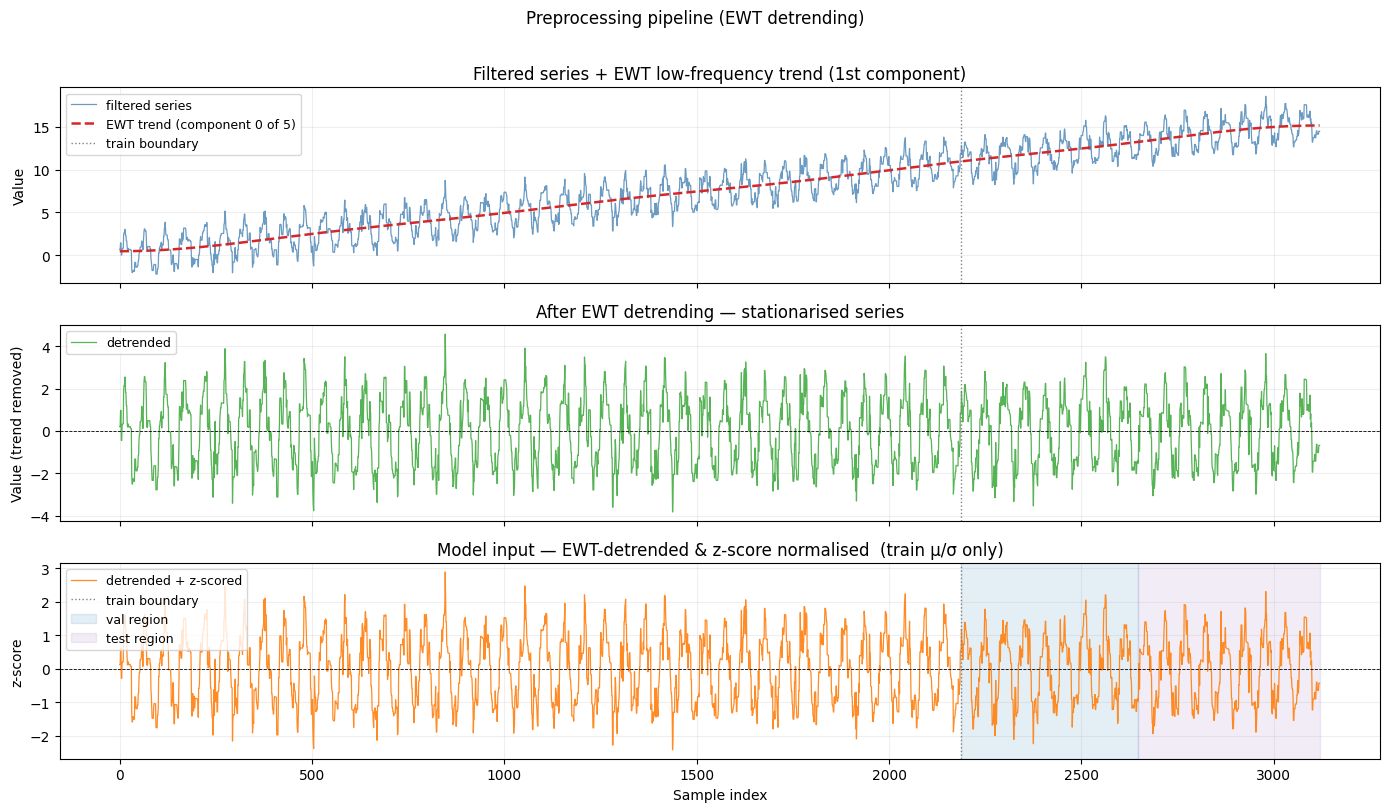

EWT boundaries  : [0.007  0.0634 0.1197 0.1077]
Train μ / σ     : -0.0021 / 1.5839

Windows — X: torch.Size([3087, 26, 1])   Y: torch.Size([3087, 8, 1])
Train: 2160  Val: 463  Test: 464
Train batches: 33  Val batches: 8


In [6]:
from foretools.ewt.ewt_core import EWT1D

SEQ_LEN    = 26   # look-back: 26 weeks (half a year)
HORIZON    = 8    # forecast: 8 weeks ahead
N_CHANNELS = 1
BATCH      = 64
EWT_N      = 5    # number of EWT components; component 0 = trend

arr   = ts_filtered.values.astype(np.float64)   # (N,)
N_arr = len(arr)

# ── 1. Train-boundary ────────────────────────────────────────────────────────
n_windows_approx = N_arr - SEQ_LEN - HORIZON
train_end = SEQ_LEN + int(0.70 * n_windows_approx)

# ── 2. EWT decomposition — first component captures the low-freq trend ────────
ewt, _, ewt_boundaries = EWT1D(arr, N=EWT_N)
trend_hat     = ewt[:, 0]          # lowest-frequency (scaling) component
arr_detrended = arr - trend_hat

# ── 3. Z-score normalise (train statistics only) ─────────────────────────────
train_mean = arr_detrended[:train_end].mean()
train_std  = arr_detrended[:train_end].std() + 1e-8
arr_norm   = ((arr_detrended - train_mean) / train_std).astype(np.float32)

# Store for inverse transform at inference time
preproc = dict(trend_hat=trend_hat, train_mean=train_mean, train_std=train_std)

def inverse_transform(x: np.ndarray, t_start: int) -> np.ndarray:
    """Undo z-score and re-add EWT trend component."""
    trend_slice = preproc["trend_hat"][t_start : t_start + len(x)]
    return x * preproc["train_std"] + preproc["train_mean"] + trend_slice

# ── 4. Diagnostic plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Panel 1: filtered series + EWT trend
axes[0].plot(arr,       color="steelblue", lw=0.9, alpha=0.8, label="filtered series")
axes[0].plot(trend_hat, color="tab:red",   lw=1.8, linestyle="--", label=f"EWT trend (component 0 of {EWT_N})")
axes[0].axvline(train_end, color="grey", lw=1.0, linestyle=":", label="train boundary")
axes[0].set_ylabel("Value"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)
axes[0].set_title("Filtered series + EWT low-frequency trend (1st component)")

# Panel 2: detrended (before normalisation)
axes[1].plot(arr_detrended, color="tab:green", lw=0.9, alpha=0.8, label="detrended")
axes[1].axhline(0,         color="black", lw=0.6, linestyle="--")
axes[1].axvline(train_end, color="grey",  lw=1.0, linestyle=":")
axes[1].set_ylabel("Value (trend removed)"); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.2)
axes[1].set_title("After EWT detrending — stationarised series")

# Panel 3: detrended + normalised (model input) with train/val/test shading
n_tot     = N_arr - SEQ_LEN - HORIZON
val_start = train_end
val_end   = train_end + int(0.15 * n_tot)
axes[2].plot(arr_norm, color="tab:orange", lw=0.9, alpha=0.9, label="detrended + z-scored")
axes[2].axhline(0,         color="black", lw=0.6, linestyle="--")
axes[2].axvline(train_end, color="grey",  lw=1.0, linestyle=":", label="train boundary")
axes[2].axvspan(val_start, val_end, alpha=0.12, color="tab:blue",   label="val region")
axes[2].axvspan(val_end,   N_arr,   alpha=0.12, color="tab:purple", label="test region")
axes[2].set_ylabel("z-score"); axes[2].set_xlabel("Sample index")
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.2)
axes[2].set_title("Model input — EWT-detrended & z-score normalised  (train μ/σ only)")

plt.suptitle("Preprocessing pipeline (EWT detrending)", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print(f"EWT boundaries  : {np.round(ewt_boundaries, 4)}")
print(f"Train μ / σ     : {train_mean:.4f} / {train_std:.4f}")

# ── 5. Sliding windows ───────────────────────────────────────────────────────
arr_2d = arr_norm.reshape(-1, 1)
xs, ys = [], []
end = len(arr_2d) - HORIZON
for i in range(SEQ_LEN, end + 1):
    xs.append(arr_2d[i - SEQ_LEN : i])
    ys.append(arr_2d[i : i + HORIZON])

X = torch.tensor(np.stack(xs), dtype=torch.float32)   # (W, SEQ_LEN, 1)
Y = torch.tensor(np.stack(ys), dtype=torch.float32)   # (W, HORIZON, 1)
print(f"\nWindows — X: {X.shape}   Y: {Y.shape}")

n       = len(X)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

X_tr, Y_tr = X[:n_train],               Y[:n_train]
X_va, Y_va = X[n_train:n_train+n_val],  Y[n_train:n_train+n_val]
X_te, Y_te = X[n_train+n_val:],         Y[n_train+n_val:]
print(f"Train: {n_train}  Val: {n_val}  Test: {n_test}")

_pin    = (DEVICE == "cuda")
_nw     = min(4, max(1, (os.cpu_count() or 2) // 2)) if DEVICE == "cuda" else 0
_common = dict(num_workers=_nw, pin_memory=_pin, persistent_workers=bool(_nw > 0))
if _nw > 0:
    _common["prefetch_factor"] = 4

train_loader = DataLoader(TensorDataset(X_tr, Y_tr), batch_size=BATCH, shuffle=True,  drop_last=True,  **_common)
val_loader   = DataLoader(TensorDataset(X_va, Y_va), batch_size=BATCH, shuffle=False, drop_last=False, **_common)
test_loader  = DataLoader(TensorDataset(X_te, Y_te), batch_size=BATCH, shuffle=False, drop_last=False, **_common)
print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")


## 4. DARTS NAS — multi-fidelity search

We restrict the operation set to operations well-suited for periodic / seasonal signals.

In [7]:
OPS = [
    "Identity",
    "ResidualMLP",
    "TimeConv",
    "TCN",
    "Fourier",
    "GRN",
    "Wavelet",
]

trainer = DARTSTrainer(
    input_dim=N_CHANNELS,
    hidden_dims=[32, 64],
    forecast_horizon=HORIZON,
    seq_length=SEQ_LEN,
    device=DEVICE,
    all_ops=OPS,
    arch_modes=["encoder_decoder"],
)
print("DARTSTrainer ready")

DARTSTrainer initialised on cuda
  input_dim=1  forecast_horizon=8
  operations available: 7
  op families: ['conv', 'frequency', 'mlp']
  arch_modes: ['encoder_decoder']
  attention_variants: ['auto']
  ffn_variants: ['auto']
DARTSTrainer ready


In [8]:
if DEVICE == "cuda":
    num_candidates = 4
    top_k          = 2
    search_epochs  = 12
    final_epochs   = 30
    max_samples    = 16
    max_workers    = min(4, _nw)
else:
    num_candidates = 2
    top_k          = 2
    search_epochs  = 8
    final_epochs   = 20
    max_samples    = 8
    max_workers    = 1

results = trainer.multi_fidelity_search(
    train_loader,
    val_loader,
    test_loader,
    num_candidates=num_candidates,
    top_k=top_k,
    search_epochs=search_epochs,
    final_epochs=final_epochs,
    max_samples=max_samples,
    max_workers=max_workers,
    retrain_final_from_scratch=True,
    discrete_arch_threshold=0.25,
    use_amp=(DEVICE == "cuda"),
)


=== Phase 1: generating + zero-cost evaluating candidates (parallel) ===
Evaluating candidate 2 with config: ['Identity', 'Wavelet', 'GRN', 'TCN'], hidden_dim=32, num_cells=1, num_nodes=3, arch_mode=encoder_decoder, families=['frequency', 'mlp', 'conv'], attn=auto, ffn=auto
Evaluating candidate 0 with config: ['Identity', 'TimeConv', 'ResidualMLP'], hidden_dim=32, num_cells=1, num_nodes=3, arch_mode=encoder_decoder, families=['conv', 'mlp'], attn=auto, ffn=auto
Evaluating candidate 1 with config: ['Identity', 'TCN', 'GRN', 'Wavelet', 'TimeConv', 'ResidualMLP', 'Fourier'], hidden_dim=32, num_cells=1, num_nodes=3, arch_mode=encoder_decoder, families=['conv', 'mlp', 'frequency'], attn=auto, ffn=auto
Evaluating candidate 3 with config: ['Identity', 'ResidualMLP', 'Wavelet', 'TCN', 'TimeConv', 'GRN', 'Fourier'], hidden_dim=64, num_cells=1, num_nodes=4, arch_mode=encoder_decoder, families=['mlp', 'frequency', 'conv'], attn=auto, ffn=auto
   Metrics: {'metrics': {'params': 2527636.0, 'condit

DARTS: 100%|██████████| 2/2 [00:13<00:00,  6.84s/epoch, train=0.0744, val=0.0711, best=0.0711, patience=0/15, conc=10.0]



Training completed in 14.1s
Best Val Loss: 0.071077
MSE: 0.978523 | MAE: 0.775724
[P3] completed rung 1 candidate id=3 | mixed_val_loss=0.071077 | train_time=14.788s total=14.788s
[P3] training rung 1 candidate 2/2 (id=2) for +2 epochs | arch_mode=encoder_decoder | families=['frequency', 'mlp', 'conv'] | attn=auto | ffn=auto
Architecture params: 35, Model params: 329
Training DARTS for 2 epochs
  Arch LR: 0.003, Model LR: 0.001
  Bilevel: True, SWA: False, AMP: True
  Cell edge budget: max_active_edges_per_node=2
  Edge regs: cosine=0.030, usage=0.040, id_cap=0.45@0.020
  MoE balance regularizer: 0.0050
  Transformer exploration regularizer: 0.0100
------------------------------------------------------------


DARTS: 100%|██████████| 2/2 [00:12<00:00,  6.01s/epoch, train=0.0876, val=0.0743, best=0.0743, patience=0/15, conc=10.0]



Training completed in 12.1s
Best Val Loss: 0.074346
MSE: 0.988746 | MAE: 0.816797
[P3] completed rung 1 candidate id=2 | mixed_val_loss=0.074346 | train_time=12.870s total=12.870s
[P3][rung 1] promoting 1/2 candidates: [3]
[P3][rung 2/4] budget=4 active=1
[P3] training rung 2 candidate 1/1 (id=3) for +2 epochs | arch_mode=encoder_decoder | families=['mlp', 'frequency', 'conv'] | attn=auto | ffn=auto
Architecture params: 41, Model params: 356
Training DARTS for 2 epochs
  Arch LR: 0.003, Model LR: 0.001
  Bilevel: True, SWA: False, AMP: True
  Cell edge budget: max_active_edges_per_node=2
  Edge regs: cosine=0.030, usage=0.040, id_cap=0.45@0.020
  MoE balance regularizer: 0.0050
  Transformer exploration regularizer: 0.0100
------------------------------------------------------------


...

Final Training: 100%|██████████| 30/30 [01:01<00:00,  2.05s/epoch, train=0.0226, val=0.0277, best_val=0.0276, patience=4/20, swa=ok]



Finalizing SWA model...


SWA val loss: 0.028148 vs best: 0.027585
Keeping original best model.

Evaluating on test set...


Test Evaluation: 100%|██████████| 8/8 [00:00<00:00, 36.34batch/s, test_loss=0.0333]


Training curve saved to final_model_training.pdf


## 5. Results

In [9]:
best = results["best_candidate"]
final = results["final_results"]
final_model = results["final_model"]

print("=== Best candidate ===")
print(f"  Zero-cost score : {best['candidate']['score']:.4f}")
print(f"  Selected ops    : {best['candidate'].get('selected_ops', 'N/A')}")
print(f"  Hidden dim      : {best['candidate'].get('hidden_dim')}")
print(f"  Val loss        : {best['val_loss']:.6f}")

print("\n=== Final model metrics ===")
for k, v in final.get("final_metrics", {}).items():
    print(f"  {k:20s}: {v:.6f}")

=== Best candidate ===
  Zero-cost score : 0.4352
  Selected ops    : ['Identity', 'ResidualMLP', 'Wavelet', 'TCN', 'TimeConv', 'GRN', 'Fourier']
  Hidden dim      : 64
  Val loss        : 0.043841

=== Final model metrics ===
  mse                 : 0.169272
  rmse                : 0.411427
  mae                 : 0.320668
  mape                : 85.865533
  r2_score            : 0.813320


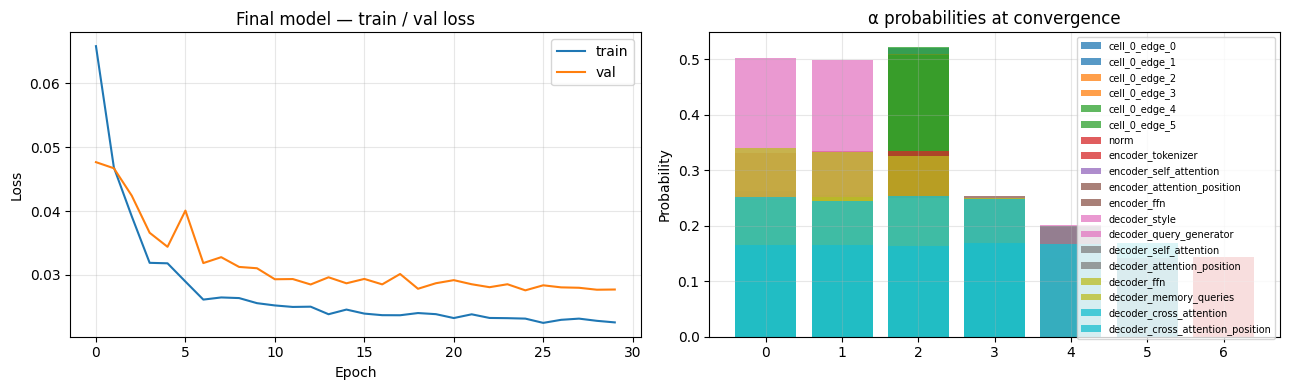

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].set_title("Final model — train / val loss")
axes[0].plot(final["train_losses"], label="train")
axes[0].plot(final["val_losses"],   label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

alpha_values = results["trained_candidates"][0]["search_results"]["alpha_values"]
if alpha_values:
    snap  = alpha_values[-1]
    names = [s[0] for s in snap]
    probs = [s[1] for s in snap]
    cmap  = plt.cm.get_cmap("tab10", len(names))
    for i, (nm, pr) in enumerate(zip(names, probs)):
        axes[1].bar(range(len(pr)), pr, label=nm, alpha=0.75, color=cmap(i))
    axes[1].set_title("α probabilities at convergence")
    axes[1].set_ylabel("Probability")
    axes[1].legend(fontsize=7, loc="upper right")
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "No α snapshots", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout(); plt.show()

## 6. Forecast vs actual — test set

1-step-ahead predictions on the held-out test windows, denormalised back to the original scale.

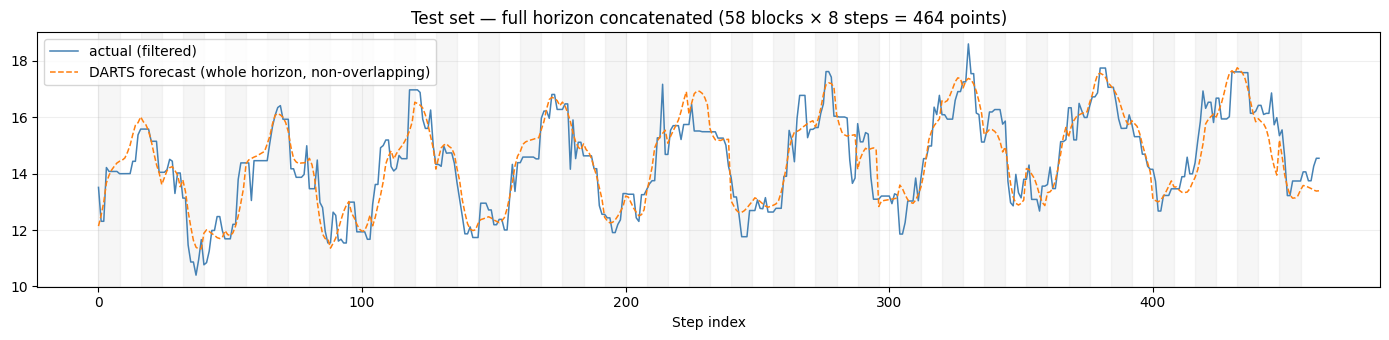

Horizon-concat  MSE: 0.42719   MAE: 0.50661   (58 blocks × 8 steps)


In [11]:
final_model.eval()
preds_list, actuals_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        out = final_model(xb.to(DEVICE)).cpu().numpy()
        preds_list.append(out)
        actuals_list.append(yb.numpy())

preds   = np.concatenate(preds_list,   axis=0)   # (N_test, ...)
actuals = np.concatenate(actuals_list, axis=0)

# Reshape if model returns flat output
if preds.ndim == 2 and preds.shape[1] == HORIZON * N_CHANNELS:
    preds   = preds.reshape(-1, HORIZON, N_CHANNELS)
    actuals = actuals.reshape(-1, HORIZON, N_CHANNELS)

# ---------------------------------------------------------------------------
# Whole-horizon concatenation
# Step through test windows in non-overlapping strides of HORIZON.
# Each stride contributes exactly one full horizon block → no overlap,
# no gap → a continuous predicted timeline on the original time axis.
# ---------------------------------------------------------------------------
CH = 0
stride_indices = list(range(0, len(preds) - HORIZON + 1, HORIZON))

# t_start for the first test window in the original arr_norm index space
t_test_start = n_train + n_val + SEQ_LEN

# Denormalise each horizon block back to the original (filtered) scale
pred_blocks   = []
actual_blocks = []
for b, i in enumerate(stride_indices):
    t_start = t_test_start + i
    pred_blocks.append(inverse_transform(preds[i, :, CH].astype(np.float64), t_start))
    actual_blocks.append(inverse_transform(actuals[i, :, CH].astype(np.float64), t_start))

pred_concat   = np.concatenate(pred_blocks)
actual_concat = np.concatenate(actual_blocks)

n_blocks  = len(stride_indices)
block_ids = np.arange(len(pred_concat))

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(block_ids, actual_concat, lw=1.1, color="steelblue",  label="actual (filtered)")
ax.plot(block_ids, pred_concat,   lw=1.1, color="tab:orange",
        linestyle="--", label="DARTS forecast (whole horizon, non-overlapping)")

# Shade alternating blocks so horizon boundaries are visible
for b in range(n_blocks):
    x0, x1 = b * HORIZON, b * HORIZON + HORIZON
    if b % 2 == 0:
        ax.axvspan(x0, x1, alpha=0.07, color="grey")

ax.set_title(f"Test set — full horizon concatenated ({n_blocks} blocks × {HORIZON} steps = {len(pred_concat)} points)")
ax.set_xlabel("Step index"); ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

mse = float(np.mean((pred_concat - actual_concat) ** 2))
mae = float(np.mean(np.abs(pred_concat - actual_concat)))
print(f"Horizon-concat  MSE: {mse:.5f}   MAE: {mae:.5f}   ({n_blocks} blocks × {HORIZON} steps)")


### 6b. Multi-step horizon fan chart

All 8 horizon steps for a rolling sample of test windows.

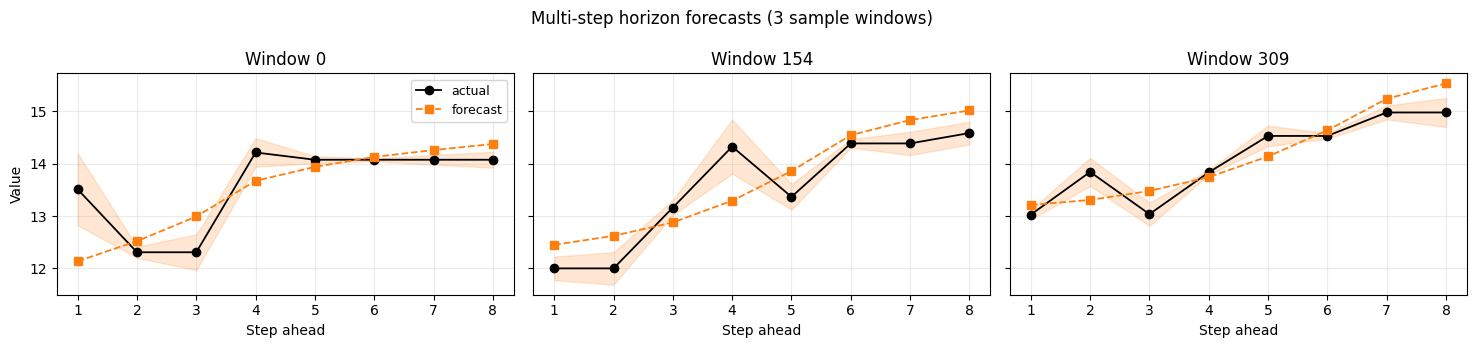

In [12]:
# Pick 3 evenly spaced test windows to visualise full horizon
n_te = len(preds)
sample_indices = [0, n_te // 3, 2 * n_te // 3]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
for ax, idx in zip(axes, sample_indices):
    t_start = t_test_start + idx
    p = inverse_transform(preds[idx, :, 0].astype(np.float64),   t_start)
    a = inverse_transform(actuals[idx, :, 0].astype(np.float64), t_start)
    ax.plot(range(1, HORIZON + 1), a, "o-",  color="black",      lw=1.3, label="actual")
    ax.plot(range(1, HORIZON + 1), p, "s--", color="tab:orange", lw=1.3, label="forecast")
    ax.fill_between(range(1, HORIZON + 1),
                    a - 0.5 * abs(a - p),
                    a + 0.5 * abs(a - p),
                    alpha=0.18, color="tab:orange")
    ax.set_title(f"Window {idx}")
    ax.set_xlabel("Step ahead")
    ax.grid(alpha=0.25)

axes[0].legend(fontsize=9)
axes[0].set_ylabel("Value")
fig.suptitle("Multi-step horizon forecasts (3 sample windows)", fontsize=12)
plt.tight_layout(); plt.show()


## 7. Discrete architecture summary

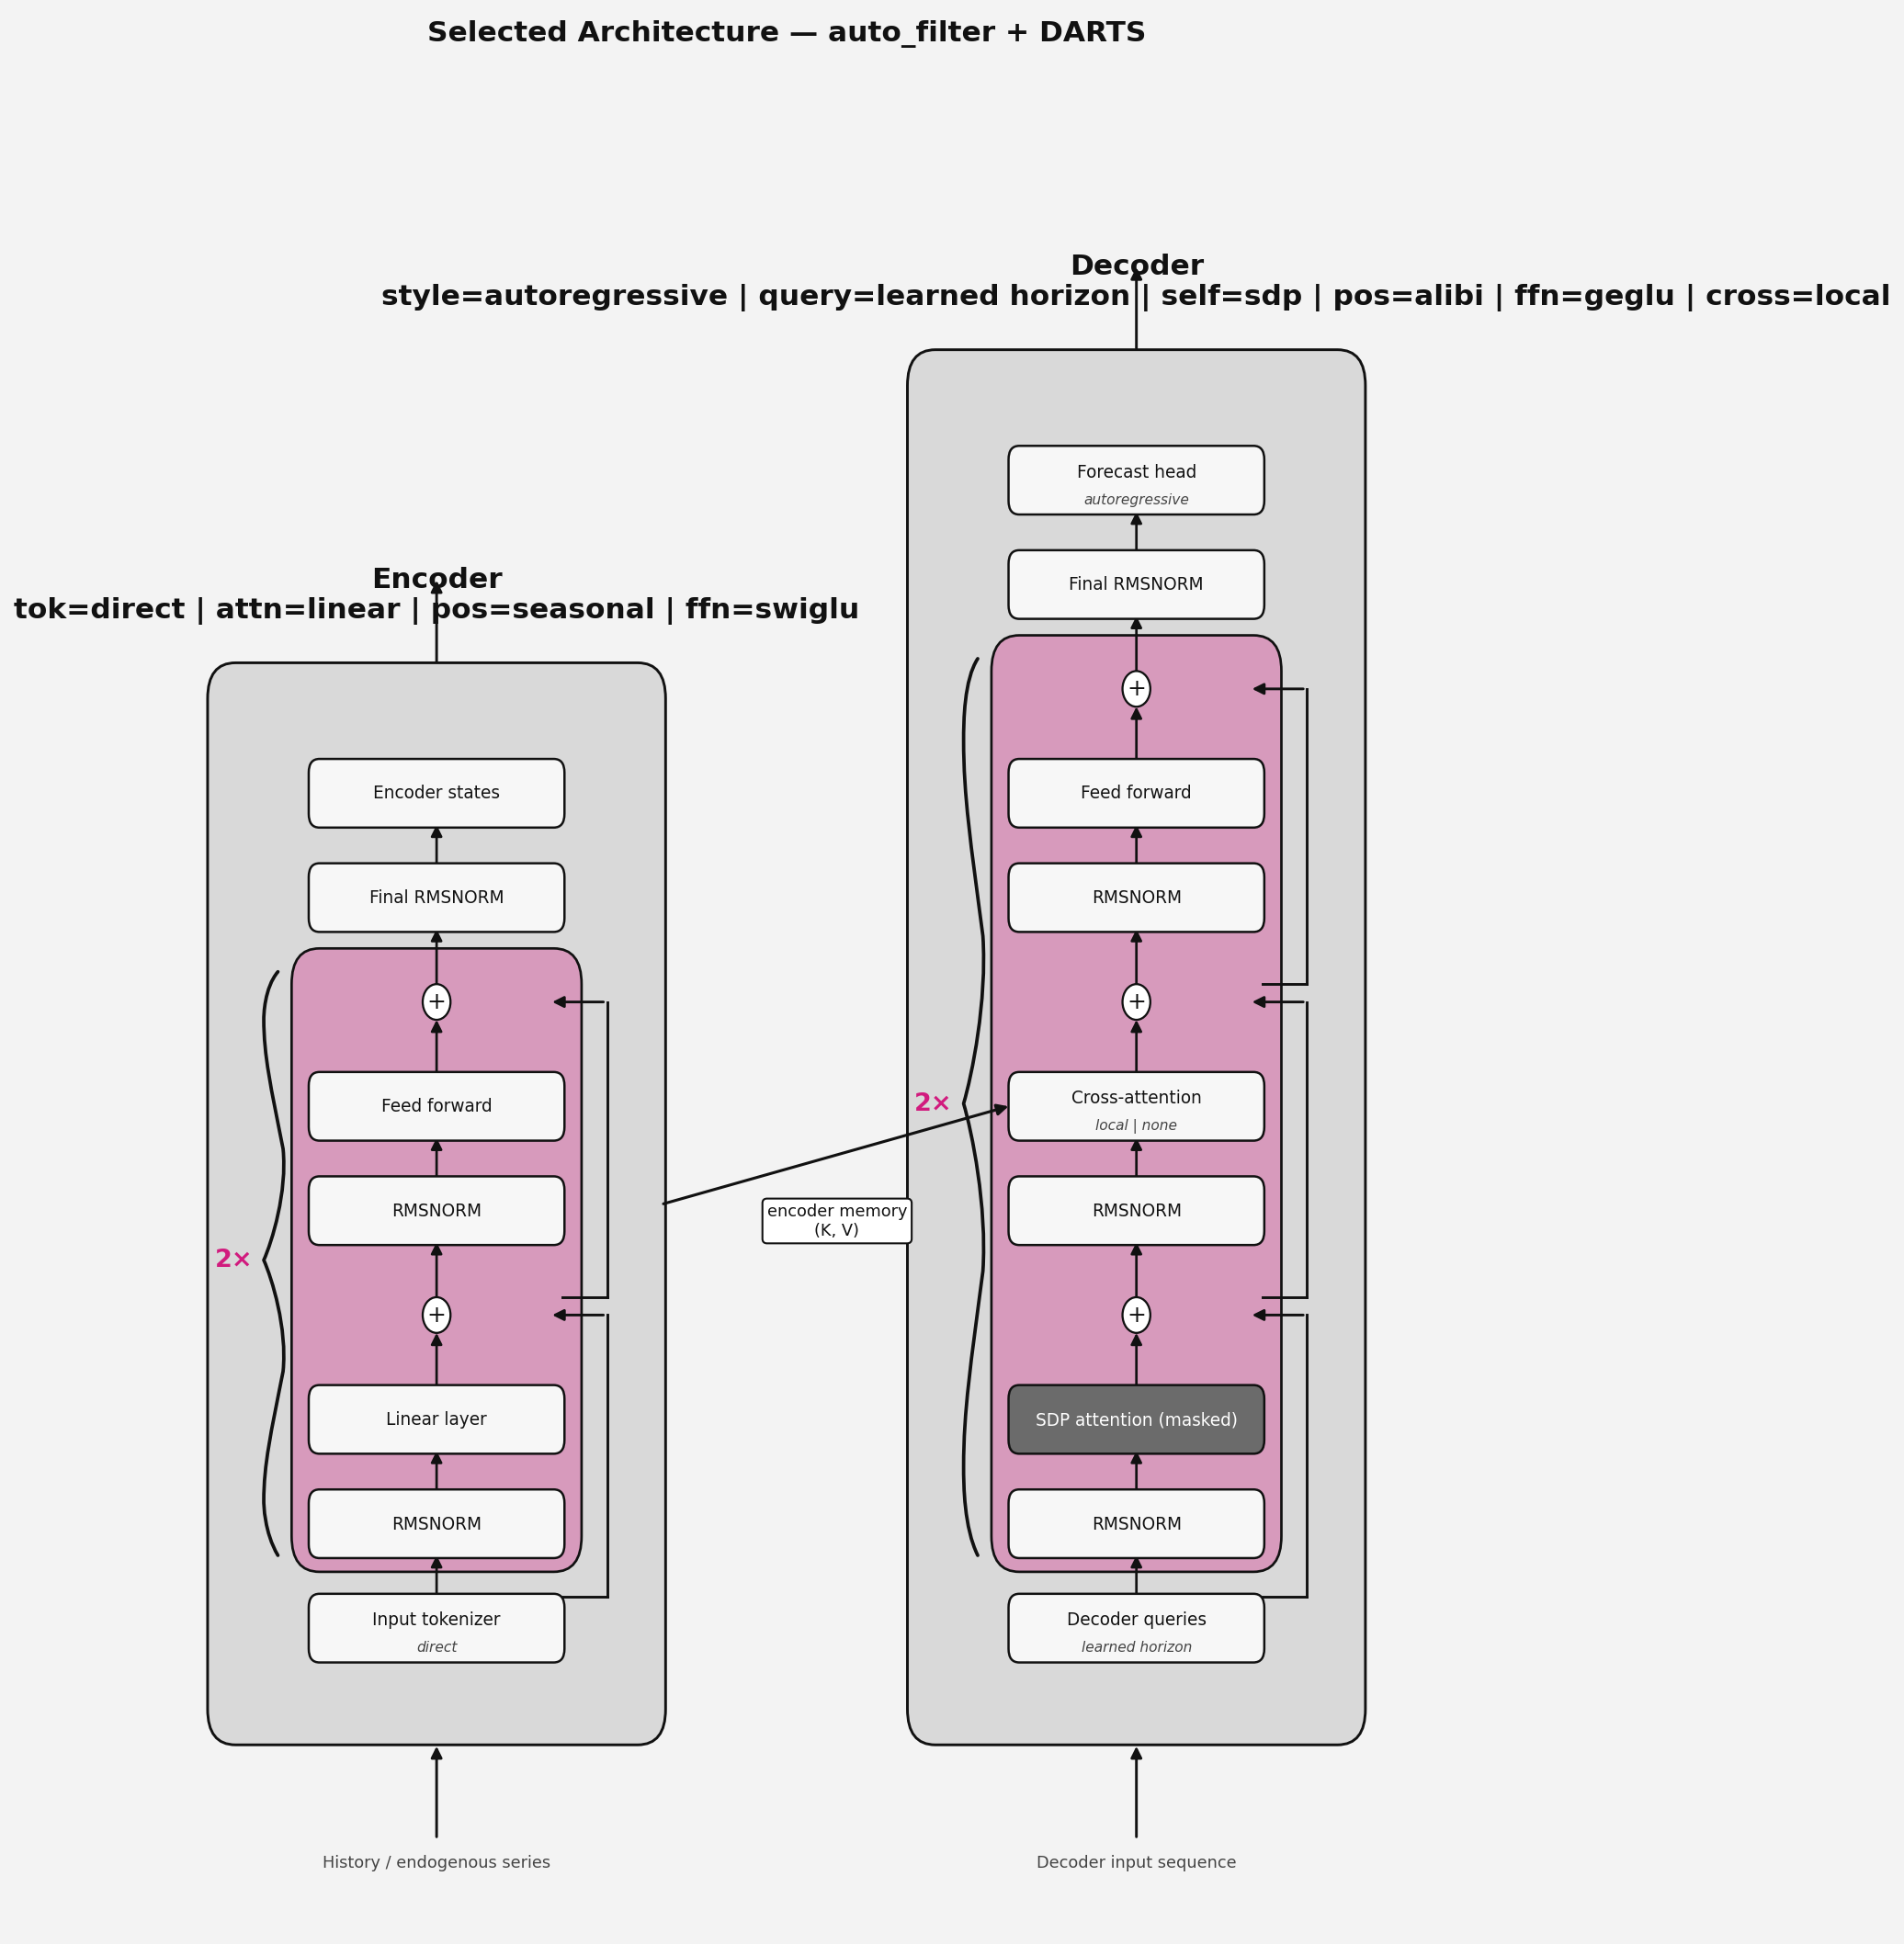

Discrete architecture:
  norm: {'type': 'instance_norm', 'weight': 1.0, 'passed_threshold': True}
  encoder: {'type': 'transformer', 'weight': 1.0, 'passed_threshold': True}
  decoder: {'type': 'transformer', 'weight': 1.0, 'passed_threshold': True}


In [13]:
from foreblocks.darts.transformer_diagram import draw_selected_transformer_architecture

fig, ax = draw_selected_transformer_architecture(
    final_model,
    title="Selected Architecture — auto_filter + DARTS",
)
plt.show()

if hasattr(final_model, "derive_discrete_architecture"):
    discrete = final_model.derive_discrete_architecture(threshold=0.25)
    print("Discrete architecture:")
    for k, v in discrete.items():
        print(f"  {k}: {v}")

In [14]:
phase_summary = results.get("stats", {}).get("phase_summary", {})
if phase_summary:
    print("Wall-clock time per phase:")
    total = 0.0
    for ph, info in phase_summary.items():
        t = info.get("wall_time_sec", 0.0)
        if ph != "total":
            total += t
        print(f"  {ph:12s}: {t:.1f}s")
    print(f"  {'TOTAL':12s}: {total:.1f}s")
else:
    print("(timing stats not collected)")

print(f"\nPipeline summary:")
print(f"  Filter used     : {best_name}")
print(f"  MSE improvement : {100*(1 - mse_filtered_vs_clean/mse_noisy_vs_clean):.1f}% noise reduction")
print(f"  DARTS ops       : {best['candidate'].get('selected_ops')}")
print(f"  Forecast MSE    : {mse:.5f}")

(timing stats not collected)

Pipeline summary:
  Filter used     : TV Denoising
  MSE improvement : 53.8% noise reduction
  DARTS ops       : ['Identity', 'ResidualMLP', 'Wavelet', 'TCN', 'TimeConv', 'GRN', 'Fourier']
  Forecast MSE    : 0.42719
